In [ ]:
from PIL import Image
import torch
from transformers import CLIPTextModel,CLIPTokenizer
from diffusers import AutoencoderKL,UNet2DConditionModel,PNDMScheduler

加载组件

In [ ]:
vae=AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4",subfolder="vae",cache_dir="./cache",use_safetensors=True)

tokenizer=CLIPTokenizer.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="tokenizer",cache_dir="./cache")

text_encoder=CLIPTextModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4",cache_dir="./cache",subfolder="text_encoder", use_safetensors=True
)

unet=UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", cache_dir="./cache",subfolder="unet", use_safetensors=True)

用UniPcMultistepScheduler来代替默认的PNDMScheduler以了解插入其他调度程序是容易的

In [ ]:
from diffusers import UniPCMultistepScheduler

虽然Scheduler用了from_pretrained，但其实Scheduler是没有可训练参数的，这里下载的是一个config文件

In [ ]:
scheduler=UniPCMultistepScheduler.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="scheduler",cache_dir="./cache")

为了加速推理，把模型都转移到GPU上

In [9]:
torch_device="cuda:0"
vae.to(torch_device)
text_encoder.to(torch_device)
unet.to(torch_device)

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

创建文本嵌入，文本嵌入作为Unet模型的条件，将扩散过程引导到类似于输入prompt的内容

In [29]:
prompt=["a photograph of an anstront riding a house"]
height=512 # Stable Diffusion默认的高
width=512 # Stable Diffusion默认的宽
num_inference_steps=25 # 去噪步数
guidance_scale=7.5 # Classifier-free guidance的Scale
generator=torch.manual_seed(0) # 设置随机种子，更详细的理解可参考: https://blog.csdn.net/qq_42951560/article/details/112174334
generator=torch.Generator(device=torch_device)
batch_size=len(prompt)

将文本分词(tokenizer),并将分词放入文本编码器中获得编码

In [15]:
text_input=tokenizer(prompt,padding="max_length",max_length=tokenizer.model_max_length,truncation=True,return_tensors="pt")

print(text_input)

with torch.no_grad():
    text_embeddings=text_encoder(text_input.input_ids.to(torch_device))[0]

{'input_ids': tensor([[49406,   320,  8853,   539,   550,   514,  4165,   339,  6765,   320,
          1212, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0]])}


同时，我们还要生成一些无条件的文本嵌入，这些嵌入是padding token的嵌入，这些无条件的文本嵌入要求和有条件的text_embedding有相同的形状(batch_size,seq_length)

In [16]:
max_length=text_input.input_ids.shape[-1]
uncond_input=tokenizer([""]*batch_size,padding="max_length",max_length=max_length,return_tensors="pt")
uncond_embeddings=text_encoder(uncond_input.input_ids.to(torch_device))[0] # [batch_size,max_length,768]

将有条件和无条件的embedding连接到一个batch中以避免执行两次前向传递

In [18]:
text_embeddings=torch.cat([uncond_embeddings,text_embeddings])

print(text_embeddings.shape)

torch.Size([2, 77, 768])


创建随机噪声：
接下来，生成一些初始随机噪声作为扩散过程的起点，这是图像的潜在表示并将逐渐去噪
此时，潜在图像的大小小于最终图像的大小，但没关系，因为模型稍后会将其转化为最终的512*512图像尺寸

In [30]:
latents=torch.randn(size=(batch_size,unet.config.in_channels,height//8,width//8),generator=generator,device=torch_device)

对图像进行降噪

首先使用初始噪声分布(sigma，噪声标度值)缩放输入，这是改进的调度程序(如UniPCMultistepScheduler所必须的)

In [31]:
latents=latents*scheduler.init_noise_sigma

1.0


最后一步是创建去噪循环，该循环逐步将潜伏中的纯噪声转换为提示描述的图像，去噪循环需要做三件事：

1.设置Scheduler在降噪期间使用的时间步长

2.迭代时间步长

3.在每个时间步，调用Unet模型来预测noise residual并将其传递给Scheduler以计算之前的噪声样本

In [35]:
from tqdm.auto import tqdm

scheduler.set_timesteps(num_inference_steps)

for t in tqdm(scheduler.timesteps):
    # 当我们要做classifier_free_guidance的时候扩展latents来避免做两次前向扩散过程
    latent_model_input=torch.cat([latents]*2)
    
    # 从代码上看怎么进怎么出，先放在这里
    latent_model_input=scheduler.scale_model_input(latent_model_input,timestep=t)
    
    # 预测noise residual
    with torch.no_grad():
        
        noise_pred=unet(latent_model_input,t,encoder_hidden_states=text_embeddings).sample
    
    # 将有条件的noise_residual和无条件的noise_residual线性组合一下
    noise_pred_uncond,noise_pred_text=noise_pred.chunk(2)
    noise_pred=noise_pred_uncond+guidance_scale*(noise_pred_text-noise_pred_uncond)
    
    # Scheduler拿到noise_residual t 以及latents来计算包含更少噪声的t-1时刻的图像
    latents=scheduler.step(noise_pred,t,latents).prev_sample    

  0%|          | 0/25 [00:00<?, ?it/s]

C:\Users\Shipu\anaconda3\envs\diffusers_use\lib\site-packages\diffusers\models\attention_processor.py:1279: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  hidden_states = F.scaled_dot_product_attention(


将latents放到解码器中

In [36]:
latents=1/0.18215*latents
with torch.no_grad():
    image=vae.decode(latents).sample

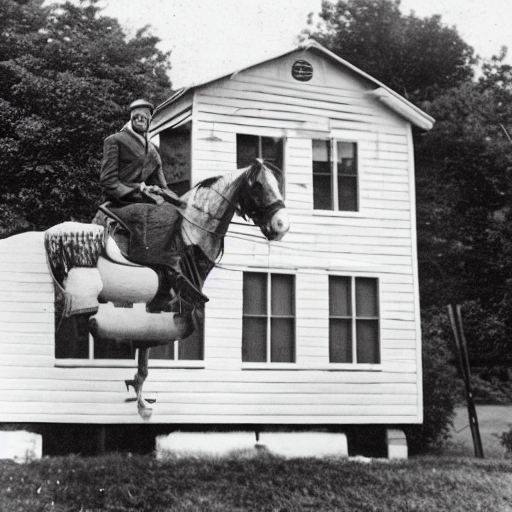

In [37]:
image = (image / 2 + 0.5).clamp(0, 1).squeeze()
image = (image.permute(1, 2, 0) * 255).to(torch.uint8).cpu().numpy()
image = Image.fromarray(image)
image